In [1]:
import json
from pathlib import Path


In [ ]:
basepath = "/Users/hmack/Development/smartrodent_experiments/runs"

detect_paths = ["detect001", "detect005", "detect01", "detect02"]

model_paths = [
    "yoloe_rodentornot",
    "yoloe_animalornot",
    "yolo26",
    "speciesnet",
    "biotrove-clip_species_names",
    "biotrove-clip_sub_df",
    "biotrove-clip_common_names",
    "biotrove-clip_animalornot",
]

species_classes = [
    "Rattus norvegicus",
    "Rattus rattus",
    "Mus musculus",
    "Myodes glareolus",
    "Apodemus agrarius",
    "Apodemus flavicollis",
    "Apodemus sylvaticus",
    "Microtus arvalis",
    "Microtus agrestis",
    "Crocidura leucodon",
]

common_name_classes = [
    "brown rat",
    "black rat",
    "house mouse",
    "bank vole",
    "striped field mouse",
    "yellow-necked mouse",
    "wood mouse",
    "common vole",
    "field vole",
    "bicolored white-toothed shrew",
]

animal_or_not = [
    "This is a photo of an animal like a mouse, rat, cat, fox, or hamster",
    "This is not a photo an animal at all, but a photo of something else entirely like trash, a car, a plastic box or a piece of wood or a leaf",
]

sub_df = [
    "This is a photo of a rodent like a rat, mouse or vole, or similar small mammal like a shrew",
    "This is a photo of not a rodent at all, but some other animal like a snake, bird or human ",
]

# when it has found these it has found the animal in the picture
yolo_animal_found = ["animal", "bear", "cat", "sheep", "cow", "dog", "bird"]

# when it reports these it has found the animal in the picture
species_net_animal_found = ["animal", "species", "family", "mammal"]

model_classes = {
    "yoloe_rodentornot": sub_df,
    "yoloe_animalornot": animal_or_not,
    "yolo26": yolo_animal_found,
    "speciesnet": species_net_animal_found,
    "biotrove-clip_species_names": species_classes,
    "biotrove-clip_sub_df": sub_df,
    "biotrove-clip_common_names": common_name_classes,
    "biotrove-clip_animalornot": animal_or_not,
}

In [4]:
data = dict()
for dp in detect_paths:
    if dp not in data:
        data[dp] = dict()

    for mp in model_paths:
        if mp not in data[dp]:
            data[dp][mp] = dict()
        path = Path(basepath) / dp / mp / "central-europe"

        for sp in path.iterdir():
            if sp.name not in data[dp][mp]:
                data[dp][mp][sp.name] = dict()

            if ".DS_Store" in str(sp):
                continue
            results = json.loads((sp / "detections.json").read_text())

            for species, detects in results.items():
                for entry in detects:
                    cls = entry["class"]
                    conf = entry["conf"]

                    if mp == "yolo26":
                        if cls in [
                            "bird",
                            "bear",
                            "cat",
                            "dog",
                            "sheep",
                            "elephant",
                            "cow",
                            "giraffe",
                            "horse",
                            "zebra",
                        ]:
                            cls = "animal"
                        else:
                            cls = "nonanimal"

                    if cls not in data[dp][mp][sp.name]:
                        data[dp][mp][sp.name][cls] = dict()
                        data[dp][mp][sp.name][cls]["count"] = 1
                        data[dp][mp][sp.name][cls]["conf"] = [
                            conf,
                        ]
                    else:
                        data[dp][mp][sp.name][cls]["count"] += 1
                        data[dp][mp][sp.name][cls]["conf"].append(conf)

data

{'detect001': {'yoloe_rodentornot': {'Apodemus flavicollis': {'This is a photo of not a rodent at all, but some other animal like a snake, bird or human ': {'count': 1294,
     'conf': [0.36,
      0.048,
      0.027,
      0.022,
      0.015,
      0.013,
      0.609,
      0.058,
      0.01,
      0.331,
      0.043,
      0.035,
      0.025,
      0.013,
      0.589,
      0.018,
      0.012,
      0.729,
      0.016,
      0.014,
      0.012,
      0.011,
      0.011,
      0.037,
      0.014,
      0.013,
      0.229,
      0.063,
      0.043,
      0.036,
      0.012,
      0.011,
      0.13,
      0.066,
      0.012,
      0.718,
      0.019,
      0.223,
      0.042,
      0.035,
      0.022,
      0.045,
      0.025,
      0.019,
      0.065,
      0.045,
      0.027,
      0.021,
      0.017,
      0.012,
      0.011,
      0.364,
      0.04,
      0.018,
      0.012,
      0.011,
      0.121,
      0.088,
      0.027,
      0.02,
      0.013,
      0.012,
      0.031,
      

In [63]:
import numpy as np
import pandas as pd

conf_summary_rows = []

for detect_path, models in data.items():
    for model_name, species_results in models.items():
        for species_name, class_results in species_results.items():
            for class_name, class_counts in class_results.items():
                if "conf" not in class_counts:
                    continue

                conf = np.asarray(class_counts["conf"], dtype=float)
                conf_summary_rows.append({
                    "detect_path": detect_path,
                    "model": model_name,
                    "species": species_name,
                    "class": class_name,
                    "count": conf.size,
                    "min": np.min(conf),
                    "q1": np.percentile(conf, 25),
                    "median": np.percentile(conf, 50),
                    "q3": np.percentile(conf, 75),
                    "max": np.max(conf),
                    "mean": np.mean(conf),
                })

conf_summary_df = pd.DataFrame(conf_summary_rows)
conf_summary_df

,detect_path,model,species,class,count,min,q1,median,q3,max,mean
0,detect001,yoloe_rodentornot,Apodemus flavicollis,"This is a photo of not a rodent at all, but so...",1294,0.010,0.01400,0.0215,0.04800,0.849,0.070895
1,detect001,yoloe_rodentornot,Apodemus flavicollis,"This is a photo of a rodent like a rat, mouse ...",551,0.010,0.02200,0.0960,0.40700,0.883,0.228374
2,detect001,yoloe_rodentornot,Rattus rattus,"This is a photo of a rodent like a rat, mouse ...",354,0.010,0.01900,0.0605,0.30600,0.918,0.188633
3,detect001,yoloe_rodentornot,Rattus rattus,"This is a photo of not a rodent at all, but so...",908,0.010,0.01400,0.0220,0.05900,0.884,0.073578
4,detect001,yoloe_rodentornot,Rattus norvegicus,"This is a photo of not a rodent at all, but so...",695,0.010,0.01400,0.0220,0.04350,0.779,0.058164
...,...,...,...,...,...,...,...,...,...,...,...
1857,detect02,biotrove-clip_animalornot,Mus musculus,"not an animal at all, but a photo of something...",159,0.509,0.82850,0.9830,0.99900,1.000,0.908050
1858,detect02,biotrove-clip_animalornot,Microtus arvalis,"not an animal at all, but a photo of something...",90,0.524,0.83300,0.9795,0.99900,1.000,0.910022
1859,detect02,biotrove-clip_animalornot,Microtus arvalis,"an animal like a mouse, rat, cat, fox, or hamster",74,0.518,0.84450,0.9655,0.99375,1.000,0.904405
1860,detect02,biotrove-clip_animalornot,Microtus agrestis,"not an animal at all, but a photo of something...",124,0.517,0.80825,0.9675,0.99900,1.000,0.891839


In [64]:
conf_summary_df["class_canonical"] = (
       conf_summary_df["class"]
         .str.replace(r"^This is a photo of\s+", "", regex=True)
         .str.replace(r"^This is not a photo\s+", "", regex=True)
         .str.strip()
   )


conf_summary_df

,detect_path,model,species,class,count,min,q1,median,q3,max,mean,class_canonical
0,detect001,yoloe_rodentornot,Apodemus flavicollis,"This is a photo of not a rodent at all, but so...",1294,0.010,0.01400,0.0215,0.04800,0.849,0.070895,"not a rodent at all, but some other animal lik..."
1,detect001,yoloe_rodentornot,Apodemus flavicollis,"This is a photo of a rodent like a rat, mouse ...",551,0.010,0.02200,0.0960,0.40700,0.883,0.228374,"a rodent like a rat, mouse or vole, or similar..."
2,detect001,yoloe_rodentornot,Rattus rattus,"This is a photo of a rodent like a rat, mouse ...",354,0.010,0.01900,0.0605,0.30600,0.918,0.188633,"a rodent like a rat, mouse or vole, or similar..."
3,detect001,yoloe_rodentornot,Rattus rattus,"This is a photo of not a rodent at all, but so...",908,0.010,0.01400,0.0220,0.05900,0.884,0.073578,"not a rodent at all, but some other animal lik..."
4,detect001,yoloe_rodentornot,Rattus norvegicus,"This is a photo of not a rodent at all, but so...",695,0.010,0.01400,0.0220,0.04350,0.779,0.058164,"not a rodent at all, but some other animal lik..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1857,detect02,biotrove-clip_animalornot,Mus musculus,"not an animal at all, but a photo of something...",159,0.509,0.82850,0.9830,0.99900,1.000,0.908050,"not an animal at all, but a photo of something..."
1858,detect02,biotrove-clip_animalornot,Microtus arvalis,"not an animal at all, but a photo of something...",90,0.524,0.83300,0.9795,0.99900,1.000,0.910022,"not an animal at all, but a photo of something..."
1859,detect02,biotrove-clip_animalornot,Microtus arvalis,"an animal like a mouse, rat, cat, fox, or hamster",74,0.518,0.84450,0.9655,0.99375,1.000,0.904405,"an animal like a mouse, rat, cat, fox, or hamster"
1860,detect02,biotrove-clip_animalornot,Microtus agrestis,"not an animal at all, but a photo of something...",124,0.517,0.80825,0.9675,0.99900,1.000,0.891839,"not an animal at all, but a photo of something..."


In [65]:
conf_summary_df.loc[:, "class_canonical"].unique()

<ArrowStringArray>
[                                                    'not a rodent at all, but some other animal like a snake, bird or human',
                                                   'a rodent like a rat, mouse or vole, or similar small mammal like a shrew',
                                                                          'an animal like a mouse, rat, cat, fox, or hamster',
     'an animal at all, but a photo of something else entirely like trash, a car, a plastic box or a piece of wood or a leaf',
                                                                                                                     'animal',
                                                                                                                  'nonanimal',
                                                                                                                     'rodent',
                                                                                            

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

## Accuracy of rodent and animal identification with Yoloe and biotrove-clip

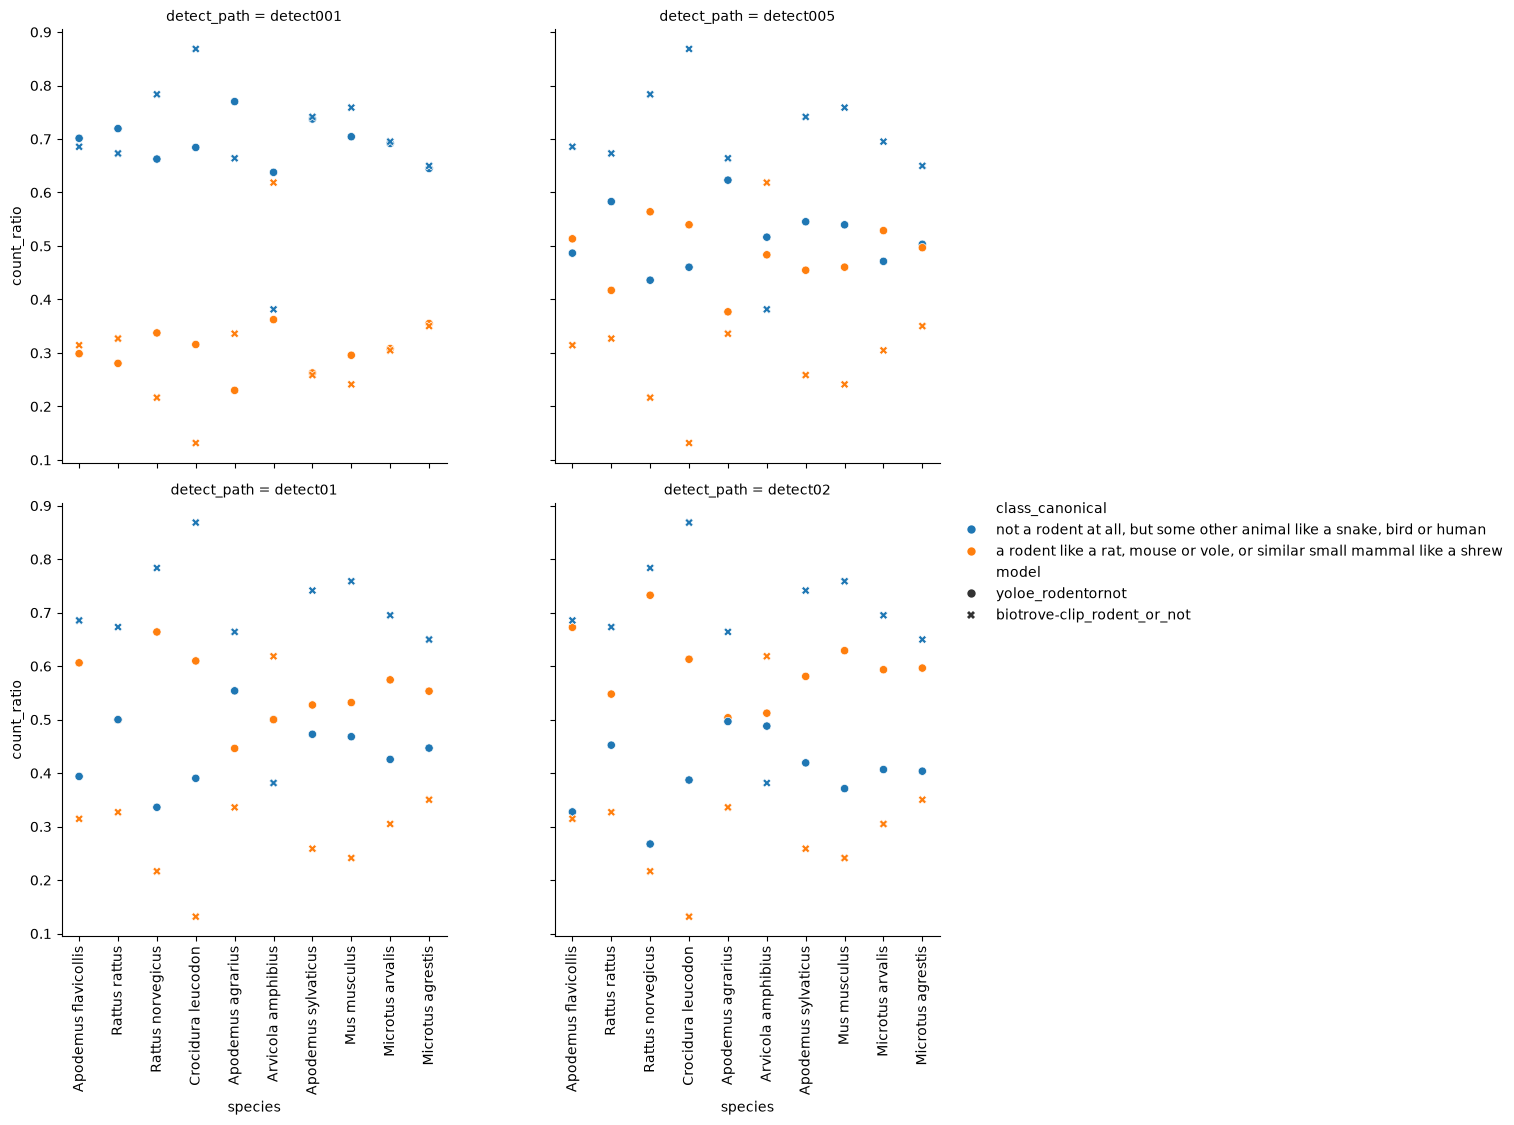

In [67]:
subset = [
       "yoloe_rodentornot",
       "biotrove-clip_rodent_or_not",
   ]
sub_df = conf_summary_df[conf_summary_df["model"].isin(subset)]

group_cols = ['detect_path', 'model', 'species',]
sub_df["count_ratio"] = (
    sub_df["count"]
    / sub_df.groupby(group_cols)["count"].transform("sum")
)

g = sns.relplot(
    sub_df,
    x = "species",
    y="count_ratio",
    hue = "class_canonical",
    style="model",
    col="detect_path",
    col_wrap=2

)

for ax in g.axes.flatten():
    ax.tick_params(axis='x', labelrotation=90)

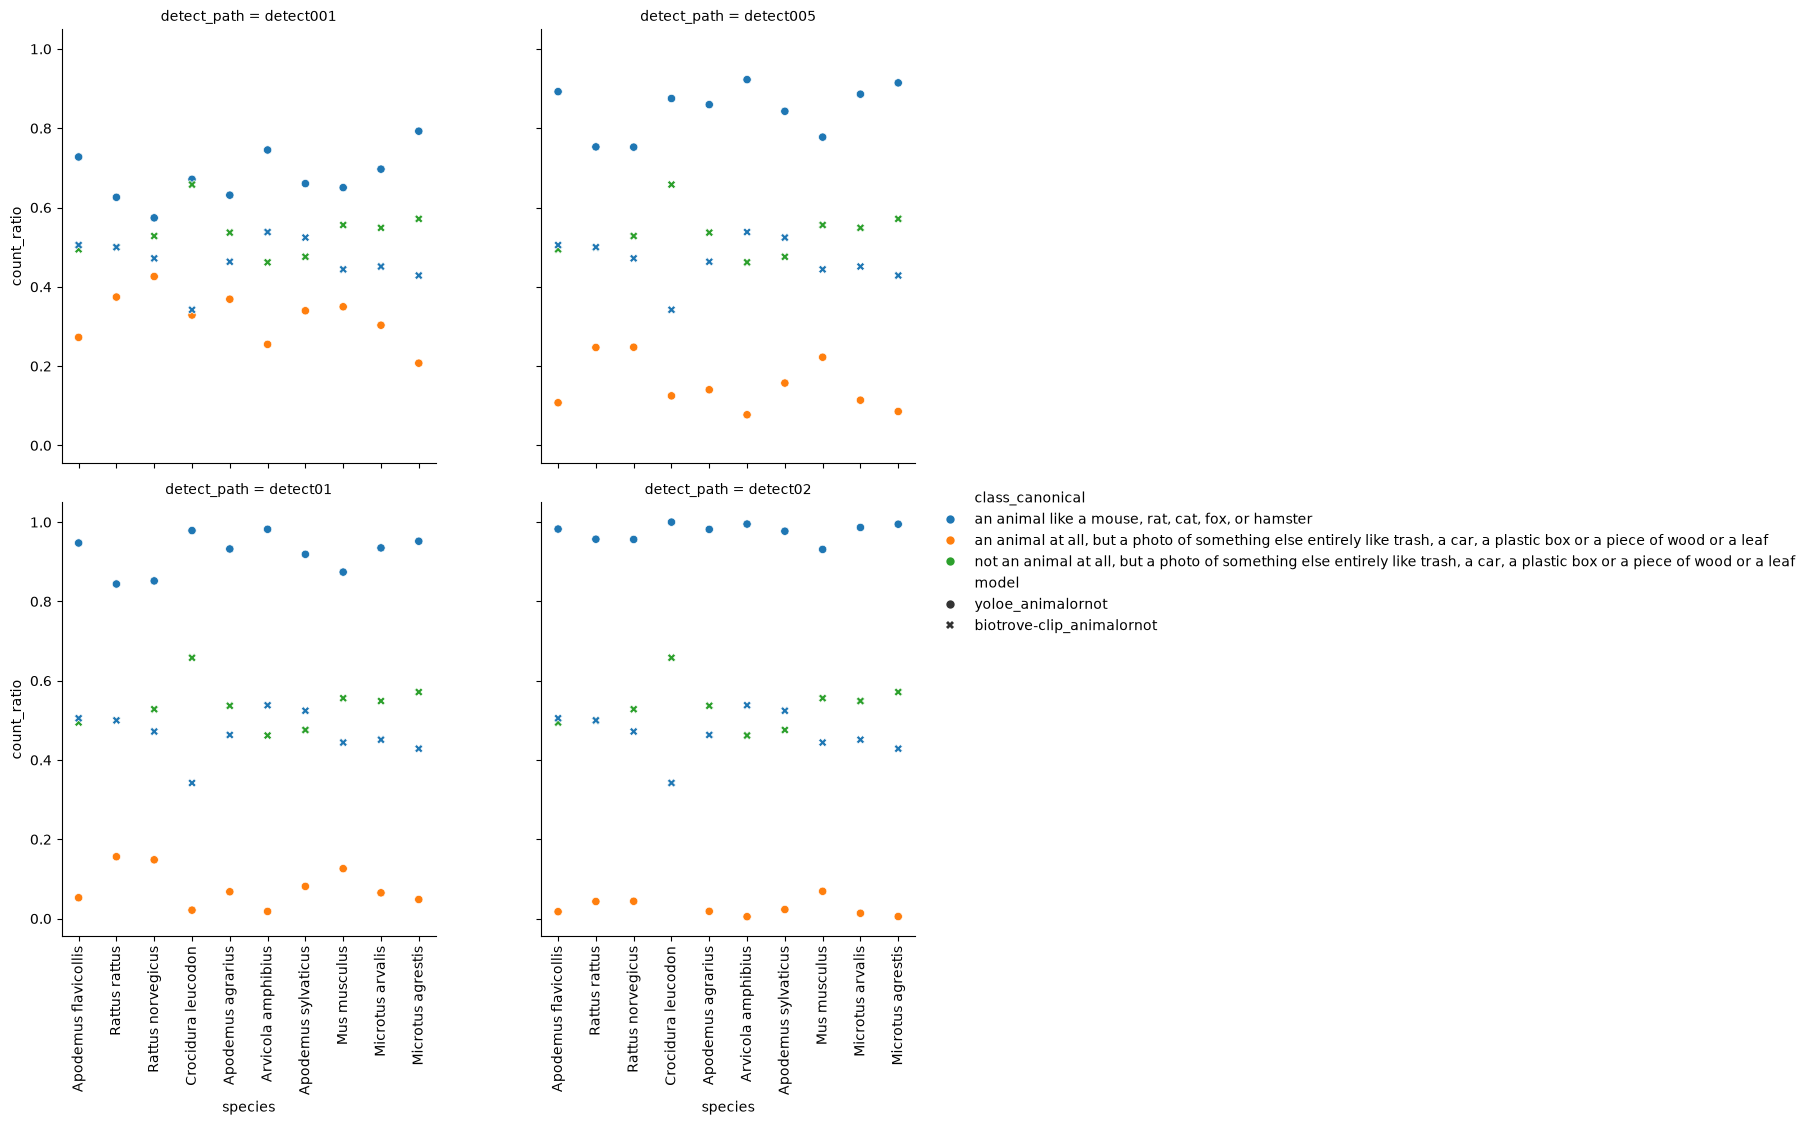

In [68]:
subset = [
       "yoloe_animalornot",
       "biotrove-clip_animalornot",
   ]
sub_df = conf_summary_df[conf_summary_df["model"].isin(subset)]

group_cols = ['detect_path', 'model', 'species',]
sub_df["count_ratio"] = (
    sub_df["count"]
    / sub_df.groupby(group_cols)["count"].transform("sum")
)

g = sns.relplot(
    sub_df,
    x = "species",
    y="count_ratio",
    hue = "class_canonical",
    style="model",
    col="detect_path",
    col_wrap=2

)

for ax in g.axes.flatten():
    ax.tick_params(axis='x', labelrotation=90)

It seems that yoloe can reliably detect animals, but rodents not so much. Biotrove clip is largely useless

## Speciesnet animal identification accuracy
We might be able to identify animals with speciesnet, then train a yolo model on its bounding boxes (**check license first if this is permissible**), and then use that to get good animal crops but with a more accessible API. Yolo is far stronger in that regard than speciesnet. Alternatively, if speciesnet would work, we could fine tune it too. **Check if speciesnet can be retrained or finetuned**

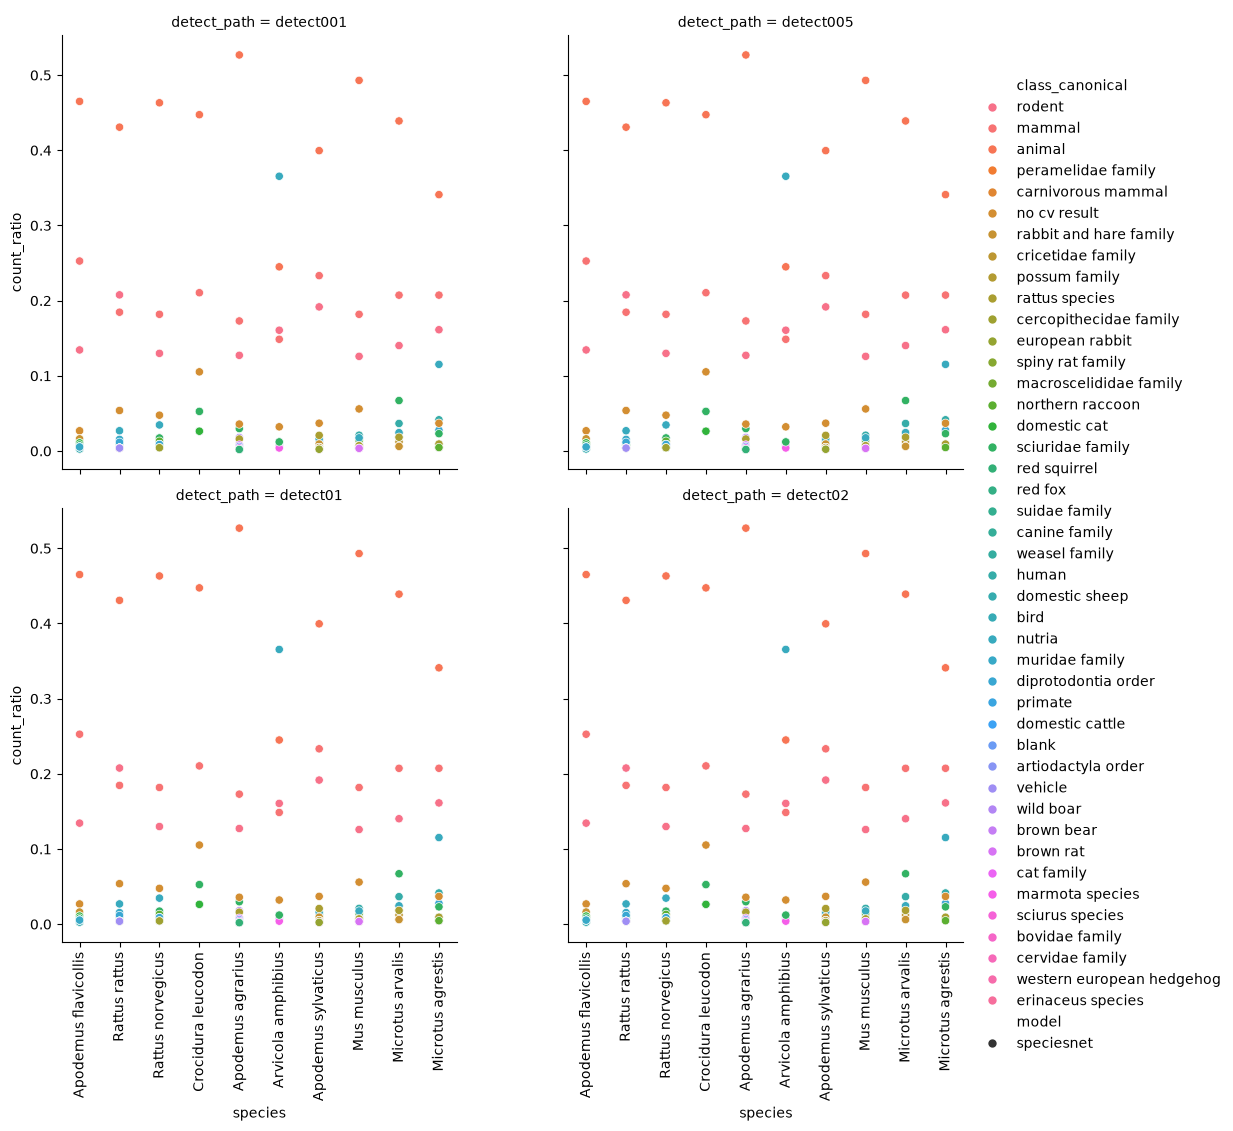

In [115]:
subset = [
       "speciesnet",
   ]
sub_df = conf_summary_df[conf_summary_df["model"].isin(subset)]

group_cols = ['detect_path', 'model', 'species',]
sub_df["count_ratio"] = (
    sub_df["count"]
    / sub_df.groupby(group_cols)["count"].transform("sum")
)

g = sns.relplot(
    sub_df,
    x = "species",
    y="count_ratio",
    hue = "class_canonical",
    style="model",
    col="detect_path",
    col_wrap=2

)

for ax in g.axes.flatten():
    ax.tick_params(axis='x', labelrotation=90)

## consolidate classes into 'animal' and 'not animal' classes 

In [116]:
non_animal = [
    "vehicle",
    "blank",
    "human",
    "no cv result"
]
animal = [a for a in sub_df["class_canonical"].unique() if a not in non_animal]
animal, non_animal

(['rodent',
  'mammal',
  'animal',
  'peramelidae family',
  'carnivorous mammal',
  'rabbit and hare family',
  'cricetidae family',
  'possum family',
  'rattus species',
  'cercopithecidae family',
  'european rabbit',
  'spiny rat family',
  'macroscelididae family',
  'northern raccoon',
  'domestic cat',
  'sciuridae family',
  'red squirrel',
  'red fox',
  'suidae family',
  'canine family',
  'weasel family',
  'domestic sheep',
  'bird',
  'nutria',
  'muridae family',
  'diprotodontia order',
  'primate',
  'domestic cattle',
  'artiodactyla order',
  'wild boar',
  'brown bear',
  'brown rat',
  'cat family',
  'marmota species',
  'sciurus species',
  'bovidae family',
  'cervidae family',
  'western european hedgehog',
  'erinaceus species'],
 ['vehicle', 'blank', 'human', 'no cv result'])

#

In [125]:
speciesnet_summary = conf_summary_df[conf_summary_df["model"].eq("speciesnet")].copy()
group_cols = ['detect_path', 'model', 'species',]



In [126]:
speciesnet_summary["is_animal"] = np.where(
speciesnet_summary["class_canonical"].str.lower().str.strip().isin(animal),
       "animal",
       "no animal",
   )

group_cols = ["detect_path", "model", "species"]

speciesnet_animal_summary = (
    speciesnet_summary
    .groupby(group_cols + ["is_animal"], as_index=False, dropna=False)["count"]
    .sum()
)

speciesnet_animal_summary["count_ratio"] = (
    speciesnet_animal_summary["count"]
    / speciesnet_animal_summary.groupby(group_cols)["count"].transform("sum")
)


In [127]:
speciesnet_animal_summary

,detect_path,model,species,is_animal,count,count_ratio
0,detect001,speciesnet,Apodemus agrarius,animal,481,0.956262
1,detect001,speciesnet,Apodemus agrarius,no animal,22,0.043738
2,detect001,speciesnet,Apodemus flavicollis,animal,360,0.967742
3,detect001,speciesnet,Apodemus flavicollis,no animal,12,0.032258
4,detect001,speciesnet,Apodemus sylvaticus,animal,409,0.944573
...,...,...,...,...,...,...
75,detect02,speciesnet,Mus musculus,no animal,27,0.094406
76,detect02,speciesnet,Rattus norvegicus,animal,215,0.930736
77,detect02,speciesnet,Rattus norvegicus,no animal,16,0.069264
78,detect02,speciesnet,Rattus rattus,animal,242,0.930769


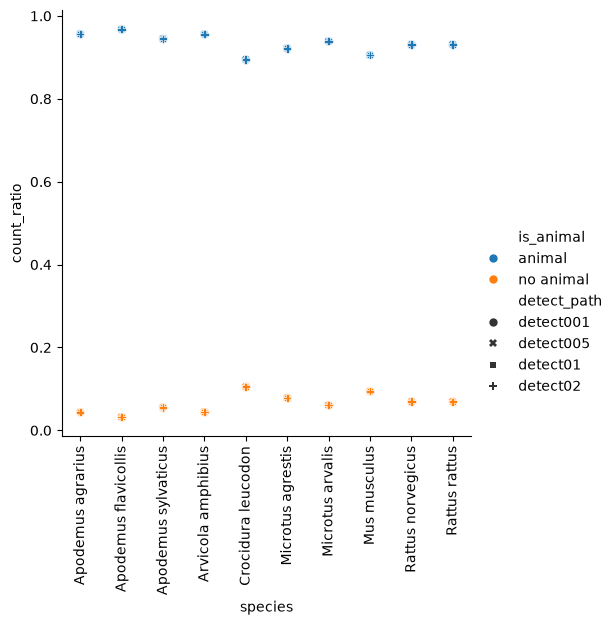

In [128]:
g = sns.relplot(
    speciesnet_animal_summary,
    x = "species",
    y="count_ratio",
    hue = "is_animal",
    style="detect_path",

)

for ax in g.axes.flatten():
    ax.tick_params(axis='x', labelrotation=90)

I was unsuccessful atm to change the confidence limit for speciesnet. however, it is rather confident in animal predictions, so extracting speciesnet crops could work well. Need to look it up better

## Train models

In [3]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

In [5]:
for k, v in model.ckpt["train_args"].items():
    print(k, ": ", v)

task :  detect
mode :  train
model :  yolo26n-objv1-150.pt
data :  /home/lq/codes/ultralytics/ultralytics/cfg/datasets/coco.yaml
epochs :  245
time :  None
patience :  100
batch :  128
imgsz :  640
save :  True
save_period :  -1
cache :  False
device :  5
workers :  8
project :  tune-yolo26n-objv1-coco
name :  train31
exist_ok :  False
pretrained :  True
optimizer :  MuSGD
verbose :  True
seed :  0
deterministic :  True
single_cls :  False
rect :  False
cos_lr :  False
close_mosaic :  10
resume :  False
amp :  True
fraction :  1.0
profile :  False
freeze :  None
multi_scale :  0.0
compile :  False
overlap_mask :  True
mask_ratio :  4
dropout :  0.0
val :  True
split :  val
save_json :  True
conf :  None
iou :  0.7
max_det :  300
half :  False
dnn :  False
plots :  False
source :  None
vid_stride :  1
stream_buffer :  False
visualize :  False
augment :  False
agnostic_nms :  False
classes :  None
retina_masks :  False
embed :  None
show :  False
save_frames :  False
save_txt :  False
sa